# 03. 모델링 — 학습·튜닝·선택·평가·오류 분석

DAY 1 보고서 5장의 전략을 그대로 실행한다. 핵심 함수는 `src/train.py`에 있고 (`python src/train.py`로 한 번에 실행 가능), 여기서는 단계별 결과와 해석을 남긴다.

| 단계 | DAY 1 전략 | 이 노트북 |
|---|---|---|
| 분할 | 충전 정책 단위 Train / Valid(Hold-out), Batch 2·3는 1회 평가 | §1 |
| 튜닝·비교 | 후보 모델 × 피처 세트, 정책 단위 GroupKFold | §2 |
| 선택 | ① Valid MAPE ② 과대예측 ③ CV–Valid 차이 ④ 단순함 | §3 |
| 테스트 | Batch 1 전체로 재학습 → Batch 2·3 각 1회 | §4 |
| 해석 | Gap, 그룹별 오차, 최소 수명 점검, 논문 비교 | §5~§6 |
| 추가 실험 | 선택 후 참고: 다른 후보의 테스트 성능, 50사이클, 재보정, 비용 환산, 보수적 교체 기준 | §7~§11 |

시작 전 예상(H1~H7)은 `results/day2_hypotheses.md`에 모델 학습 전에 적어 두었다.

In [1]:
import sys, json, warnings
sys.path.insert(0, '../src')
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import train as T
from features import build_dataset, FEATURE_SETS
import viz
viz.setup()
pd.set_option('display.width', 180); pd.set_option('display.max_colwidth', 80)

df = build_dataset()
ok = df[df.status == 'OK']
b1 = ok[ok.batch == 'b1'].reset_index(drop=True)
b2 = ok[ok.batch == 'b2']; b3 = ok[ok.batch == 'b3']

## 1. 데이터 분할

- Batch 1 36셀을 **충전 정책 단위**로 약 75% / 25%로 나눈다. 정책이 20개이고 대부분 쌍둥이 셀(같은 정책 2개)이라, 셀 단위로 무작위로 나누면 쌍둥이 한쪽은 학습, 다른 쪽은 검증에 들어가 *답을 미리 본* 효과가 생긴다.
- 노션은 이 누수 때문에 Valid를 CV 대신 Hold-out으로 하라고 했다. 우리는 Hold-out도 정책 단위로 나누고, Train 안의 CV(튜닝용)도 정책 단위 GroupKFold로 해서 같은 누수를 CV에서도 막았다.

In [2]:
train, valid = T.split_batch1(b1)
print(f'Train {len(train)}셀 / 정책 {train.group.nunique()}개')
print(f'Valid {len(valid)}셀 / 정책 {valid.group.nunique()}개')
print('겹치는 정책:', set(train.group) & set(valid.group) or '없음')
print('Valid 수명 범위:', int(valid.cycle_life.min()), '~', int(valid.cycle_life.max()),
      '/ Train:', int(train.cycle_life.min()), '~', int(train.cycle_life.max()))

Train 28셀 / 정책 15개
Valid 8셀 / 정책 5개
겹치는 정책: 없음
Valid 수명 범위: 617 ~ 1074 / Train: 534 ~ 1054


## 2. 하이퍼파라미터 튜닝과 후보 비교 (Batch 1 안에서만)

| 모델 | 튜닝한 값 | 피처 세트 | 넣은 이유 (DAY 1 근거) |
|---|---|---|---|
| 평균 예측 | — | — | 기준선. 이것보다 못하면 모델이 의미 없음 |
| 선형 회귀 | 없음 | A | log ΔQ–log 수명이 직선 (4.3). 원논문 'variance' 모델 재현 |
| ElasticNet | 규제 세기 alpha, L1 비율 | B·C·D | 피처를 늘리면 중복(VIF 수백) → 규제 필요 (4.5) |
| 랜덤포레스트 | 깊이, 잎 최소 셀 수 | A·B·C | 비선형이 있는지 확인. 단 학습 범위 밖 예측 불가 (4.1) |
| 그래디언트부스팅 | 나무 수, 학습률, 깊이 | A·B·C | 〃 |

- 튜닝: Train 셀 안에서 GridSearchCV + 정책 단위 GroupKFold(5겹), 점수는 MAPE.
- 타깃은 log10(수명)으로 학습하고, MAPE는 사이클 수로 되돌려 계산한다.
- 셀이 적어서(28개) 탐색 범위는 일부러 작게 잡았다.

In [3]:
table, fitted = T.compare_models(train, valid)
show = table.drop(columns='최적파라미터').round(2)
show

,모델,피처세트,피처수,Train_CV_MAPE,Valid_MAPE,Valid_과대예측비율,Gap_Train_Valid
0,평균 예측,A,1,14.31,22.53,37.5,8.22
1,선형 회귀,A,1,9.03,9.29,37.5,0.27
2,ElasticNet,B,3,10.02,11.27,37.5,1.25
3,ElasticNet,C,12,6.00,9.47,37.5,3.47
4,ElasticNet,D,8,12.41,20.31,37.5,7.90
5,랜덤포레스트,A,1,9.48,10.68,12.5,1.20
6,랜덤포레스트,B,3,9.84,11.04,37.5,1.19
7,랜덤포레스트,C,12,10.22,12.58,37.5,2.37
8,그래디언트부스팅,A,1,9.09,10.32,25.0,1.23
9,그래디언트부스팅,B,3,9.13,10.41,12.5,1.28


In [4]:
table[['모델', '피처세트', '최적파라미터']]

,모델,피처세트,최적파라미터
0,평균 예측,A,{}
1,선형 회귀,A,{}
2,ElasticNet,B,"{""alpha"": 0.01, ""l1_ratio"": 0.5}"
3,ElasticNet,C,"{""alpha"": 0.01, ""l1_ratio"": 0.1}"
4,ElasticNet,D,"{""alpha"": 0.01, ""l1_ratio"": 0.9}"
5,랜덤포레스트,A,"{""max_depth"": 2, ""min_samples_leaf"": 1, ""n_estimators"": 300}"
6,랜덤포레스트,B,"{""max_depth"": 2, ""min_samples_leaf"": 5, ""n_estimators"": 300}"
7,랜덤포레스트,C,"{""max_depth"": 2, ""min_samples_leaf"": 5, ""n_estimators"": 300}"
8,그래디언트부스팅,A,"{""learning_rate"": 0.03, ""max_depth"": 1, ""n_estimators"": 100}"
9,그래디언트부스팅,B,"{""learning_rate"": 0.1, ""max_depth"": 1, ""n_estimators"": 100}"


findfont: Failed to find font weight bold for AppleGothic, now using 400.


PosixPath('/Users/leejinseo/workspace/class20/results/figures/m1_model_comparison.png')

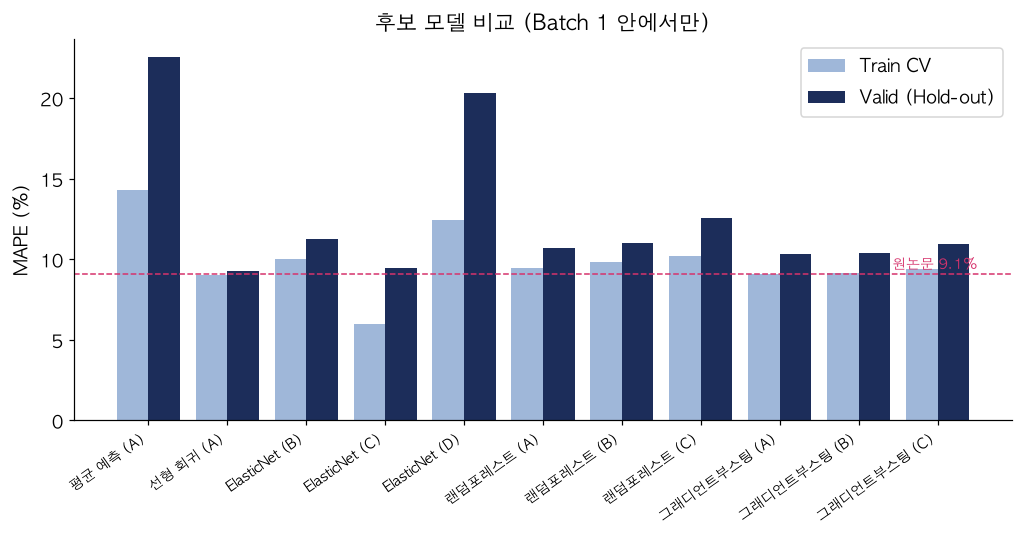

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
lab = table.모델 + ' (' + table.피처세트 + ')'
x = np.arange(len(table))
ax.bar(x - .2, table.Train_CV_MAPE, .4, label='Train CV', color='#9fb7d9')
ax.bar(x + .2, table.Valid_MAPE, .4, label='Valid (Hold-out)', color='#1C2D5A')
ax.axhline(9.1, ls='--', c='#d6336c', lw=1); ax.text(len(x) - .5, 9.4, '원논문 9.1%', color='#d6336c', ha='right', fontsize=9)
ax.set_xticks(x, lab, rotation=35, ha='right', fontsize=9); ax.set_ylabel('MAPE (%)')
ax.set_title('후보 모델 비교 (Batch 1 안에서만)'); ax.legend()
viz.save(fig, 'm1_model_comparison')

**읽는 법과 해석**

- **평균 예측(기준선)**은 Valid 22.5%. 모든 모델이 이보다 훨씬 낫다 → ΔQ에 수명 정보가 실제로 있다.
- **선형 회귀(A)**는 CV 9.0% / Valid 9.3%로 둘의 차이가 가장 작다. 피처 1개, 튜닝 없음인데 원논문 수준이다.
- **ElasticNet(C)**는 CV 6.0%로 가장 좋지만 Valid 9.5% → **CV와 Valid 차이 3.5%p**. 피처 12개로 학습 셀에 더 맞췄다가 새 정책에서는 이득이 사라진 것으로 보인다(과적합 신호).
- **ElasticNet(D, 현장 피처만)**은 Valid 20.3%로 기준선과 비슷하다 → ΔQ 없이는 예측이 거의 안 된다 (H4).
- **트리 계열**은 ΔQ 하나(A)만 써도 선형보다 1~1.5%p 나쁘다. 직선 관계를 굳이 계단 모양으로 근사하니 손해. 비선형 이득은 없었다.
- **충전 정책 추가(B)**는 어떤 모델에서도 A보다 좋아지지 않았다 (H3).

### 2-1. Valid 셀 8개는 우연에 흔들리지 않는가 (분할 seed 30번 반복)

Valid가 8셀이면 셀 한두 개로 순위가 바뀔 수 있다. 공식 표는 seed 42 하나로 쓰되, 분할을 30번 바꿔서 순위가 유지되는지 참고로 확인한다.

In [6]:
combos = [('선형 회귀', 'A'), ('ElasticNet', 'B'), ('ElasticNet', 'C'), ('랜덤포레스트', 'A'),
          ('그래디언트부스팅', 'A'), ('그래디언트부스팅', 'B')]
rep = T.repeated_holdout(b1, combos, n=30)
rep['순위'] = rep.groupby('seed').Valid_MAPE.rank()
stab = rep.groupby(['모델', '피처세트']).agg(평균=('Valid_MAPE', 'mean'), 표준편차=('Valid_MAPE', 'std'),
                                         중앙값=('Valid_MAPE', 'median'), 평균순위=('순위', 'mean'),
                                         일등횟수=('순위', lambda r: int((r == 1).sum()))).sort_values('평균')
rep.to_csv('../results/repeated_holdout.csv', index=False, encoding='utf-8-sig')
stab.round(2)

,,평균,표준편차,중앙값,평균순위,일등횟수
모델,피처세트,,,,,
ElasticNet,C,7.13,1.85,7.27,1.47,26
선형 회귀,A,9.49,2.26,8.94,3.17,0
ElasticNet,B,10.09,2.35,9.88,3.73,1
그래디언트부스팅,A,10.46,2.73,9.42,3.47,1
랜덤포레스트,A,11.22,2.70,11.10,4.57,1
그래디언트부스팅,B,11.43,2.87,11.23,4.60,1


PosixPath('/Users/leejinseo/workspace/class20/results/figures/m2_repeated_holdout.png')

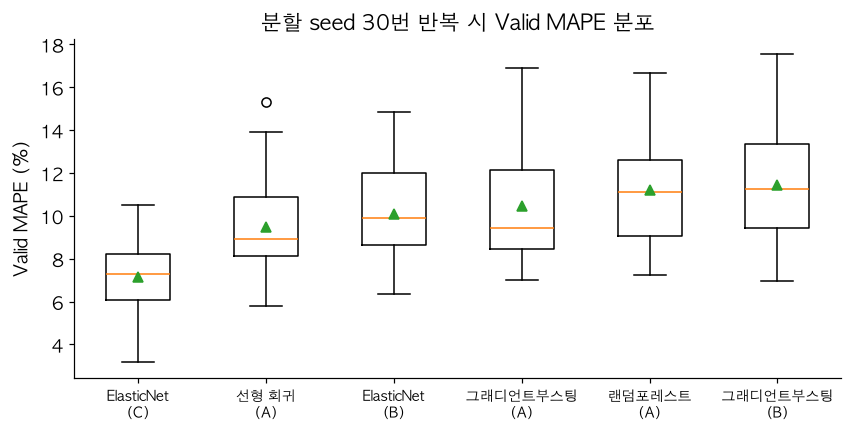

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
order = stab.index.tolist()
ax.boxplot([rep[(rep.모델 == m) & (rep.피처세트 == f)].Valid_MAPE for m, f in order],
           tick_labels=[f'{m}\n({f})' for m, f in order], showmeans=True)
ax.set_ylabel('Valid MAPE (%)'); ax.set_title('분할 seed 30번 반복 시 Valid MAPE 분포')
plt.xticks(fontsize=9)
viz.save(fig, 'm2_repeated_holdout')

**해석 — 예상과 달랐던 부분**

- 분할을 30번 바꾸면 **ElasticNet(C, 피처 12개)이 30번 중 26번 Valid 1등**이다 (평균 7.1% vs 선형 9.5%). seed 42에서 선형 회귀가 뽑힌 건 이 분할에서 둘의 차이가 0.2%p로 작았기 때문이고, 다른 seed였다면 규칙대로 ElasticNet(C)이 뽑혔을 수 있다.
- 같은 Valid 값도 seed에 따라 ±2%p 정도 움직인다 → Valid 하나를 소수점까지 비교하면 안 된다.
- 그럼 ElasticNet(C)이 더 좋은 모델인가? **Batch 1 안에서는 그렇다.** 하지만 C에는 초기 용량(`qd_2`)·충전 시간처럼 배치마다 출발점이 다른 피처가 들어 있다(02 노트북: 초기 용량의 배치 차이가 표준편차의 3.5배). Batch 1 안에서 아무리 나눠 검증해도 *배치가 바뀌는 상황*은 시험해 볼 수 없다. 이 점이 실제 테스트에서 어떻게 나타났는지는 §7에서 확인한다.

## 3. 최종 모델 선택 (DAY 1 규칙 그대로, Batch 2·3는 보지 않음)

1. Valid MAPE가 1등과 1%p 이내인 후보: 선형 회귀(A) 9.29%, ElasticNet(C) 9.47%
2. 과대예측 비율: 둘 다 37.5% (8셀 중 3셀) → 동률
3. CV–Valid 차이: 선형 0.27%p vs ElasticNet(C) 3.47%p → **선형 회귀(A)**
4. (단순함도 선형이 우위: 피처 1개, 튜닝 없음)

In [8]:
best = T.select(table)
name, fs = best.모델, best.피처세트
print('선택:', name, '/ 피처 세트', fs, FEATURE_SETS[fs])
best

선택: 선형 회귀 / 피처 세트 A ['dq100_logvar']


모델                    선형 회귀
피처세트                      A
피처수                       1
Train_CV_MAPE      9.025715
Valid_MAPE         9.291929
Valid_과대예측비율           37.5
Gap_Train_Valid    0.266215
최적파라미터                   {}
abs_gap            0.266215
복잡도                     101
Name: 1, dtype: object

## 4. 최종 학습과 테스트 (각 1회)

선택한 모델을 Batch 1 전체(36셀)로 다시 학습한다. 셀이 적어서 8셀을 버려 두기 아깝고, 설정값(튜닝)은 이미 정해졌기 때문이다.

In [9]:
model, cv_all = T.final_fit(name, fs, b1)
reg = model.regressor_.named_steps['reg']; sc = model.regressor_.named_steps['scale']
slope = reg.coef_[0] / sc.scale_[0]; intercept = reg.intercept_ - slope * sc.mean_[0]
print(f'Batch 1 전체 CV MAPE: {cv_all:.2f}%')
print(f'학습된 식: log10(수명) = {intercept:.3f} + ({slope:.3f}) × log10 Var(ΔQ)')
print(f'→ ΔQ 분산이 10배 커지면 예측 수명은 ×{10**slope:.2f} (약 {100*(1-10**slope):.0f}% 감소)')

Batch 1 전체 CV MAPE: 8.55%
학습된 식: log10(수명) = 1.762 + (-0.297) × log10 Var(ΔQ)
→ ΔQ 분산이 10배 커지면 예측 수명은 ×0.50 (약 50% 감소)


In [10]:
pred = T.predict_table(model, fs, df)
perf = T.performance_table(best.Train_CV_MAPE, best.Valid_MAPE, pred, len(train), len(valid))
pred.to_csv('../results/predictions.csv', index=False, encoding='utf-8-sig')
perf.to_csv('../results/model_performance.csv', index=False, encoding='utf-8-sig')
perf.round(2)

,구분,MAPE (%),비고
0,Train (Batch 1 CV),9.03,"Train 28셀, 정책 단위 GroupKFold 평균"
1,Valid (Batch 1 Hold-out),9.29,정책 단위 Hold-out 8셀
2,Test (Batch 2),28.56,Batch 1 전체로 재학습 후 1회 평가
3,Gap (Train-Valid),0.27,(+) : 과적합 의심
4,Gap (Valid-Test),19.27,(+) : 배치간 일반화 저하 의심
5,Gap (Target-Test),19.46,Target : 원논문 9.1%
6,Test (Batch 3),12.81,추가 검증
7,Gap (Batch2-Batch3),15.75,Test 성능 간 비교
8,"Gap (Target-Test, Batch 3)",3.71,"Batch 3 기준, 원논문 성능 비교"


## 5. 결과 해석 — Gap은 왜 생겼나

### 5-1. Batch 2를 그룹별로 쪼개 보면 (DAY 1 4.6에서 예고한 위험)

In [11]:
def summarize(d):
    y, p = d.cycle_life.values, d.pred.values
    return pd.Series({'셀': len(d), 'MAPE': T.mape(y, p), '과대예측비율(%)': T.over_ratio(y, p),
                      '오차 중앙값(%)': np.median((p - y) / y * 100),
                      '오차 중앙값(사이클)': np.median(p - y)})
po = pred[pred.status == 'OK']
grp = po.groupby(['batch', 'subgroup']).apply(summarize)
grp = pd.concat([grp, po.groupby('batch').apply(summarize).assign(subgroup='전체').set_index('subgroup', append=True)]).sort_index()
grp.to_csv('../results/error_by_group.csv', encoding='utf-8-sig')
grp.round(1)

셀  MAPE  과대예측비율(%)  오차 중앙값(%)  오차 중앙값(사이클)
batch subgroup                                                   
b1    기존 방식         36.0   8.2       52.8        1.0          6.7
      전체            36.0   8.2       52.8        1.0          6.7
b2    newstructure   9.0  17.5       88.9        6.1         55.1
      기존 방식         30.0  31.9      100.0       32.2        153.0
      전체            39.0  28.6       97.4       31.9        152.5
b3    newstructure  44.0  12.8       56.8        2.2         20.6
      전체            44.0  12.8       56.8        2.2         20.6

PosixPath('/Users/leejinseo/workspace/class20/results/figures/m3_pred_vs_actual.png')

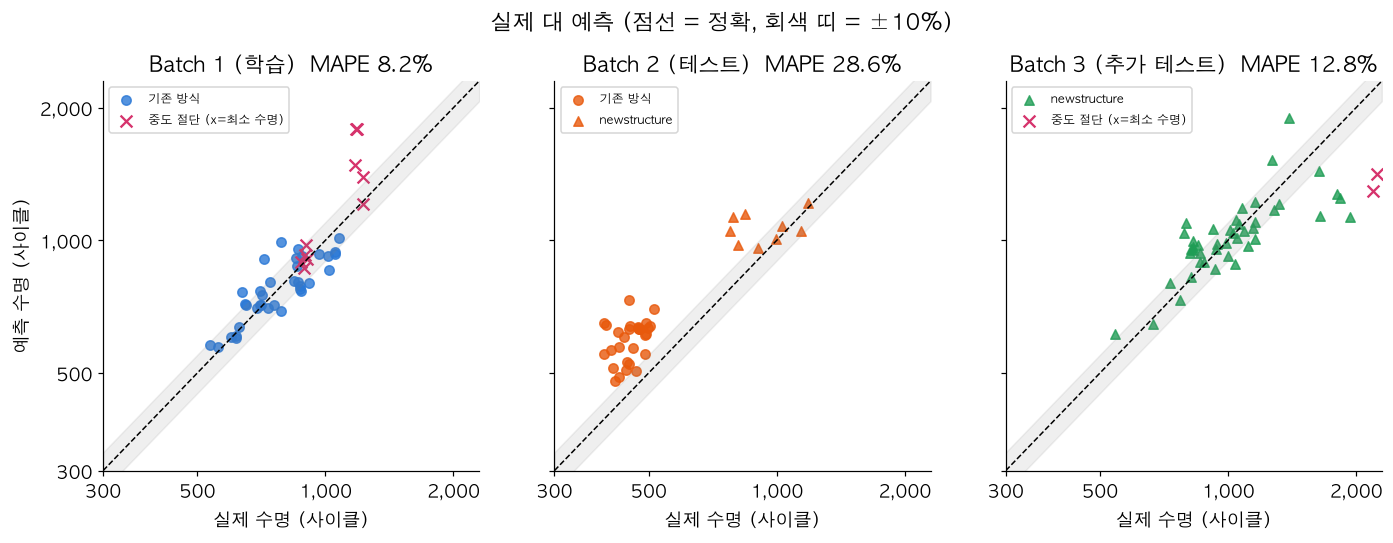

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
lim = [300, 2300]
for a, b in zip(ax, ['b1', 'b2', 'b3']):
    d = po[po.batch == b]
    for g, mk in [('기존 방식', 'o'), ('newstructure', '^')]:
        dd = d[d.subgroup == g]
        if len(dd): a.scatter(dd.cycle_life, dd.pred, marker=mk, s=38, alpha=.8, color=viz.BATCH_COLOR[b], label=g)
    c = pred[(pred.batch == b) & (pred.status == 'CENSORED')]
    if len(c): a.scatter(c.min_life, c.pred, marker='x', s=60, color='#d6336c', label='중도 절단 (x=최소 수명)')
    a.plot(lim, lim, 'k--', lw=1); a.fill_between(lim, [l * .9 for l in lim], [l * 1.1 for l in lim], color='gray', alpha=.12)
    a.set(xscale='log', yscale='log', xlim=lim, ylim=lim, title=f'{viz.BATCH_LABEL[b]}  MAPE {T.mape(d.cycle_life, d.pred):.1f}%',
          xlabel='실제 수명 (사이클)')
    a.legend(fontsize=8, loc='upper left')
    from matplotlib.ticker import FixedLocator, NullLocator, FuncFormatter
    for axis in (a.xaxis, a.yaxis):
        axis.set_major_locator(FixedLocator([300, 500, 1000, 2000])); axis.set_minor_locator(NullLocator())
        axis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax[0].set_ylabel('예측 수명 (사이클)')
fig.suptitle('실제 대 예측 (점선 = 정확, 회색 띠 = ±10%)', y=1.02)
viz.save(fig, 'm3_pred_vs_actual')

**해석**

- **Batch 1 (학습 배치)**: 대각선 주변에 고르게 퍼짐. 오차 방향 치우침 없음.
- **Batch 2 기존 방식 30셀**: **30셀 모두 대각선 위** = 전부 수명을 길게 예측했다. 오차 중앙값 +32%(153사이클). DAY 1 4.6에서 "Batch 1 관계식을 그대로 쓰면 +32%(중앙값 153사이클) 길게 잡는다"고 예고한 숫자와 같다 (H2 적중).
- **Batch 2 newstructure 9셀**: 오차 중간 수준. 이 그룹은 Batch 3과 같은 실험 방식이다.
- **Batch 3**: 대부분 ±10~20% 안. 다만 2,000사이클에 가까운 최장수명 셀은 짧게 예측했다(b3_c38: 1,935 → 1,130).
- 즉 **Batch 2의 큰 오차는 모델 전체의 문제가 아니라 '기존 방식 30셀'이라는 한 무리에 몰려 있다.** Batch 3과 같은 실험 방식인 newstructure 9셀은 17.5%로, 기존 방식(31.9%)보다 훨씬 작다.

### 5-2. 가장 크게 틀린 셀들의 공통점

In [13]:
top = po.reindex(po.err_pct.abs().sort_values(ascending=False).index).head(12)
top = top.merge(df[['cell', 'dq100_logvar', 'C_avg', 'C_max']], on='cell')
top[['batch', 'cell', 'policy', 'subgroup', 'cycle_life', 'pred', 'err_pct', 'dq100_logvar', 'C_max']].round(2)

,batch,cell,policy,subgroup,cycle_life,pred,err_pct,dq100_logvar,C_max
0,b2,b2_c06,3.6C(9%)-5C,기존 방식,393.0,648.19,64.93,-3.53,5.0
1,b2,b2_c18,5.2C(50%)-4.25C,기존 방식,449.0,731.81,62.99,-3.71,5.2
2,b2,b2_c15,3.6C(9%)-5C,기존 방식,396.0,642.11,62.15,-3.52,5.0
3,b2,b2_c02,5.2C(50%)-4.25C,기존 방식,424.0,617.96,45.75,-3.46,5.2
4,b2,b2_c09,5.6C(26%)-4.5C-newstructure,newstructure,791.0,1131.83,43.09,-4.34,5.6
5,b3,b3_c38,5C(67%)-4C-newstructure,newstructure,1935.0,1129.99,-41.60,-4.34,5.0
6,b2,b2_c29,5.2C(58%)-4C,기존 방식,452.0,638.60,41.28,-3.51,5.2
7,b2,b2_c19,6C(60%)-3C,기존 방식,392.0,550.73,40.49,-3.29,6.0
8,b2,b2_c11,5.2C(50%)-4.25C,기존 방식,449.0,628.69,40.02,-3.49,5.2
9,b2,b2_c21,6C(60%)-3C,기존 방식,408.0,563.97,38.23,-3.33,6.0


In [14]:
print('상위 12개 중 Batch 2 기존 방식:', ((top.batch == 'b2') & (top.subgroup == '기존 방식')).sum(), '개')
print('상위 12개 중 과대예측:', (top.err_pct > 0).sum(), '개')
b2o = po[(po.batch == 'b2') & (po.subgroup == '기존 방식')].merge(df[['cell', 'dq100_logvar', 'C_max', 'C_avg']], on='cell')
print('Batch 2 기존 방식 수명 범위:', int(b2o.cycle_life.min()), '~', int(b2o.cycle_life.max()))
print('Batch 2 기존 방식 안에서 오차와 상관: 최대 C-rate %.2f, ΔQ %.2f' % (
    np.corrcoef(b2o.err_pct, b2o.C_max)[0, 1], np.corrcoef(b2o.err_pct, b2o.dq100_logvar)[0, 1]))

상위 12개 중 Batch 2 기존 방식: 9 개
상위 12개 중 과대예측: 11 개
Batch 2 기존 방식 수명 범위: 392 ~ 514
Batch 2 기존 방식 안에서 오차와 상관: 최대 C-rate -0.34, ΔQ -0.72


PosixPath('/Users/leejinseo/workspace/class20/results/figures/m4_residual_by_group.png')

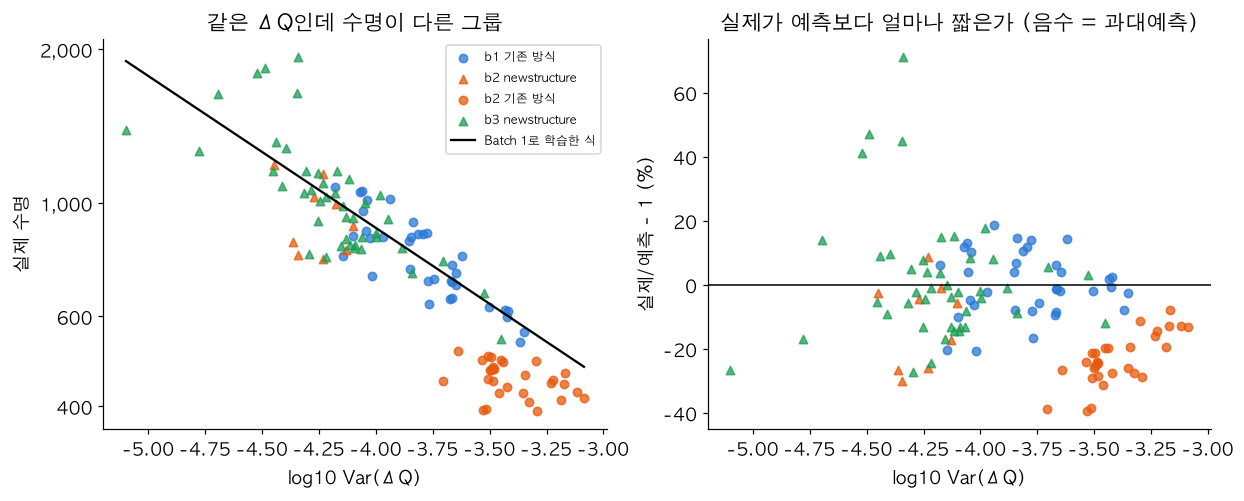

In [15]:
# 같은 ΔQ에서 그룹마다 수명이 다른가: 잔차(log) vs ΔQ
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
d = po.merge(df[['cell', 'dq100_logvar']], on='cell')
d['res'] = np.log10(d.cycle_life) - np.log10(d.pred)
for (b, g), dd in d.groupby(['batch', 'subgroup']):
    ax[0].scatter(dd.dq100_logvar, dd.cycle_life, s=30, alpha=.75, color=viz.BATCH_COLOR[b],
                  marker='o' if g == '기존 방식' else '^', label=f'{b} {g}')
    ax[1].scatter(dd.dq100_logvar, (10 ** dd.res - 1) * 100,
                  s=30, alpha=.75, color=viz.BATCH_COLOR[b], marker='o' if g == '기존 방식' else '^')
xs = np.linspace(d.dq100_logvar.min(), d.dq100_logvar.max(), 50)
ax[0].plot(xs, 10 ** (intercept + slope * xs), 'k-', lw=1.5, label='Batch 1로 학습한 식')
ax[0].set(yscale='log', xlabel='log10 Var(ΔQ)', ylabel='실제 수명', title='같은 ΔQ인데 수명이 다른 그룹')
from matplotlib.ticker import FixedLocator, NullLocator, FuncFormatter
ax[0].yaxis.set_major_locator(FixedLocator([400, 600, 1000, 2000])); ax[0].yaxis.set_minor_locator(NullLocator()); ax[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'{v:,.0f}'))
ax[0].legend(fontsize=8)
ax[1].axhline(0, c='k', lw=1)
ax[1].set(xlabel='log10 Var(ΔQ)', ylabel='실제/예측 - 1 (%)', title='실제가 예측보다 얼마나 짧은가 (음수 = 과대예측)')
viz.save(fig, 'm4_residual_by_group')

**오류 분석 결론**

- (위 출력) Batch 2 기존 방식 안에서 오차와 ΔQ의 상관이 −0.72다. ΔQ 분산이 *작은* 셀일수록(모델이 오래 산다고 본 셀일수록) 더 크게 과대예측했다. 이 그룹은 실제 수명이 392~514로 좁은데 ΔQ는 넓게 퍼져 있어서, ΔQ로 수명 차이를 구분하지 못한다는 뜻이다.

- **공통점**: 가장 크게 틀린 셀의 대부분이 *Batch 2 기존 방식*이고, 전부 *과대예측*이다. 수명이 392~514로 좁게 몰린 짧은 셀들이다.
- **원인 가설 1 — 배치(로트·실험 시기) 차이**: 왼쪽 그림에서 Batch 2 기존 방식 점들은 같은 ΔQ에서 Batch 1 선보다 아래에 있다. 같은 정책 6C(60%)-3C도 Batch 1 744 vs Batch 2 400사이클(DAY 1 4.1). 충전 조건이 같은데 수명이 다르니, ΔQ나 충전 정책으로 설명되지 않는 *배치 고유의 차이*(셀 제조 로트, 실험 시기·장비)가 있다. 노션에도 배치 수집 사이 수개월 공백이 있다고 적혀 있다.
- **원인 가설 2 — 짧은 수명 구간에서 ΔQ 관계가 평평해짐**: Batch 2 기존 방식 안에서는 ΔQ–수명 관계 기울기가 −0.08로 Batch 1(−0.30)보다 훨씬 평평하다(DAY 1 4.6). 이 구간에서는 ΔQ가 수명 차이를 잘 구분하지 못한다.
- **이건 피처를 더 넣어서 고칠 수 있는 문제가 아니다**: 충전 정책을 더한 B 세트도 Batch 2를 개선하지 못했다(§7). 해결책은 '새 배치의 일부 셀로 기준을 보정'하는 것 → §9에서 실험.

### 5-3. 중도 절단 셀 — 최소 수명 점검 (DAY 1 약속)

정답은 없지만 '최소 이만큼은 살았다'를 아는 12셀. 예측이 기록 길이보다 짧으면 **확실히 틀린** 것이다.

In [16]:
cen = pred[pred.status == 'CENSORED'].copy()
cen['위반'] = cen.pred < cen.min_life
cen['예측/최소수명'] = cen.pred / cen.min_life
print(f"위반 {cen.위반.sum()} / {len(cen)}셀")
cen[['batch', 'cell', 'policy', 'min_life', 'pred', '예측/최소수명', '위반']].round(2)

위반 4 / 12셀


,batch,cell,policy,min_life,pred,예측/최소수명,위반
0,b1,b1_c00,3.6C(80%)-3.6C,1189.0,1790.88,1.51,False
1,b1,b1_c01,3.6C(80%)-3.6C,1178.0,1789.77,1.52,False
2,b1,b1_c02,3.6C(80%)-3.6C,1176.0,1480.72,1.26,False
3,b1,b1_c03,4C(80%)-4C,1225.0,1210.50,0.99,True
4,b1,b1_c04,4C(80%)-4C,1226.0,1392.97,1.14,False
8,b1,b1_c08,5.4C(40%)-3.6C,878.0,894.86,1.02,False
10,b1,b1_c10,5.4C(50%)-3C,905.0,908.05,1.00,False
12,b1,b1_c12,5.4C(50%)-3.6C,901.0,974.12,1.08,False
13,b1,b1_c13,5.4C(50%)-3.6C,896.0,924.00,1.03,False
22,b1,b1_c22,6C(30%)-3.6C,890.0,865.33,0.97,True


**해석**

- Batch 1의 10셀은 대부분 기록 길이보다 길게 예측했다. 위반 2셀(b1_c03, b1_c22)도 1~3% 차이라 사실상 경계선이다. 학습 데이터 최장 수명(1,074)보다 긴 1,400~1,800도 예측했다 → **선형 모델이 학습 범위 밖을 예측할 수 있다**는 DAY 1 선택 이유가 실제로 작동했다.
- **Batch 3의 2셀(최소 2,189·2,237)은 1,300~1,400으로 크게 짧게 예측**했다. 아주 오래 사는 셀에서는 선형 관계도 부족하다. 학습 데이터에 1,100 이상이 없으니 그 위쪽 관계는 '직선이 계속될 것'이라는 가정에 기대는데, 실제로는 더 오래 살았다.
- 운영 관점: 짧게 예측하는 쪽은 *조기 교체(돈 낭비)*, 길게 예측하는 쪽은 *갑작스러운 정지(더 위험)*다. 이 모델의 위험한 실수는 Batch 2 기존 방식 쪽(과대예측)에 몰려 있다.

## 6. 원논문과 비교

원논문(Severson et al. 2019, Table 1)을 다시 읽어 보니 **실험 설계가 우리와 다르다**.

- 논문: Batch 1+2를 합친 84셀을 **수명 범위가 고르게 섞이도록 반씩** 학습(41)과 1차 테스트(43)로 나눔. 즉 1차 테스트에도 학습과 같은 배치의 셀이 들어 있다. Batch 3(40셀)는 모델 개발 후 만든 2차 테스트.
- 우리: Batch 1만으로 학습하고 Batch 2 전체를 테스트(노션 과제 조건). 모델이 **학습·튜닝에 한 번도 쓰지 않은 배치**를 맞히는 더 어려운 시험이다.
- 그래서 공정한 비교 상대는 '9.1%(최고 모델)'가 아니라, 우리와 같은 피처 1개짜리 **'variance' 모델**이다.

In [17]:
paper = pd.DataFrame({
    '모델': ['논문 variance (ΔQ 1개)', '논문 discharge (6개)', '논문 full (9개)', '우리 선형 회귀 (ΔQ 1개)'],
    '학습': [14.1, 9.8, 5.6, round(cv_all, 1)],
    '1차 테스트': ['14.7 (13.2)', '13.0 (10.1)', '14.1 (7.5)', f"{grp.loc[('b2', '전체'), 'MAPE']:.1f}"],
    '2차 테스트 (Batch 3)': [11.4, 8.6, 10.7, round(grp.loc[('b3', '전체'), 'MAPE'], 1)],
    '1차 테스트 구성': ['Batch 1·2 혼합 (학습과 같은 배치 포함)'] * 3 + ['Batch 2 전체 (학습·튜닝에 안 쓴 배치)'],
})
paper

,모델,학습,1차 테스트,2차 테스트 (Batch 3),1차 테스트 구성
0,논문 variance (ΔQ 1개),14.1,14.7 (13.2),11.4,Batch 1·2 혼합 (학습과 같은 배치 포함)
1,논문 discharge (6개),9.8,13.0 (10.1),8.6,Batch 1·2 혼합 (학습과 같은 배치 포함)
2,논문 full (9개),5.6,14.1 (7.5),10.7,Batch 1·2 혼합 (학습과 같은 배치 포함)
3,우리 선형 회귀 (ΔQ 1개),8.5,28.6,12.8,Batch 2 전체 (학습·튜닝에 안 쓴 배치)


In [18]:
# 논문 2차 테스트(Batch 3)는 40셀. 저자 공개 코드가 측정이 불안정한 채널로 뺀 셀(c2, c23, c32, c37, c42, c43) 중
# c23·c32는 우리도 이미 제외(중도 절단) → 나머지 4셀을 빼면 논문과 같은 40셀
paper_drop = ['b3_c02', 'b3_c37', 'b3_c42', 'b3_c43']
b3_40 = po[(po.batch == 'b3') & ~po.cell.isin(paper_drop)]
print(f'Batch 3 전체 {(po.batch == "b3").sum()}셀 MAPE {T.mape(*po[po.batch == "b3"][["cycle_life", "pred"]].values.T):.2f}%')
print(f'논문과 같은 {len(b3_40)}셀 MAPE {T.mape(b3_40.cycle_life, b3_40.pred):.2f}%  (논문 variance 모델 11.4%)')
po[po.cell.isin(paper_drop)][['cell', 'policy', 'cycle_life', 'pred', 'err_pct']].round(1)

Batch 3 전체 44셀 MAPE 12.81%
논문과 같은 40셀 MAPE 11.75%  (논문 variance 모델 11.4%)


,cell,policy,cycle_life,pred,err_pct
87,b3_c02,5.6C(19%)-4.6C-newstructure,1267.0,1524.3,20.3
122,b3_c37,4.8C(80%)-4.8C-newstructure,1390.0,1896.8,36.5
127,b3_c42,4.8C(80%)-4.8C-newstructure,1642.0,1133.2,-31.0
128,b3_c43,5C(67%)-4C-newstructure,1046.0,1110.6,6.2


- 괄호 안 값은 논문에서 수명이 매우 짧은 이상 셀 1개를 뺀 값이다. 우리 데이터 정리에서도 Batch 2의 정답 없는 셀은 제외했다.
- 우리 학습 셀은 Batch 1의 CV 값이고 논문은 학습 오차라 기준이 완전히 같지는 않다.

**비교 해석**

1. **같은 배치 안에서는 논문만큼 된다**: 우리 Batch 1 CV 약 8.5%는 논문 variance 모델 학습 오차(14.1%)보다 낮다. ΔQ 하나만으로 원논문의 핵심 결론('100사이클 시점 곡선 변화로 수명을 예측할 수 있다')을 재현했다.
2. **다른 배치(Batch 3)도 논문과 비슷하다**: 논문과 같은 40셀로 맞추면 11.75% vs 논문 11.4%로 0.35%p 차이다(44셀 전체로는 12.8%). 학습 셀이 41 → 36개로 적은데도 거의 같다.
3. **Batch 2에서만 크게 벌어진다**: 28.6% vs 논문 14.7%. 논문은 Batch 2 셀 일부로 학습했기 때문에 Batch 2의 '짧게 사는 성질'을 모델이 이미 배웠다. 우리 모델은 Batch 2를 학습·튜닝에 쓰지 않았다(과제가 지정한 최종 평가 데이터). 단 DAY 1 EDA에서 사람이 Batch 2의 분포와 수명은 봤으므로 완전한 블라인드 테스트는 아니다. **Gap(Target−Test)의 대부분은 모델이 나빠서가 아니라 시험 조건이 달라서 생긴 것**이다.
4. 배운 점: '논문 9.1%'라는 숫자 하나만 보면 우리 모델이 3배 나쁘다고 오해할 수 있다. 성능 숫자를 비교할 때는 *어떤 데이터로 학습하고 무엇을 시험했는지*를 먼저 맞춰 봐야 한다.

## 7. (선택 후 참고) 다른 후보들은 테스트에서 어땠을까

> 모델은 §3에서 이미 확정했다. 여기서는 **선택에 쓰지 않고**, "다른 걸 골랐다면 어땠을까"를 배우기 위해 본다. 각 후보를 Batch 1 전체로 재학습해 Batch 2·3에 적용했다.

In [19]:
rows = []
for (m, f), _ in fitted.items():
    if m == '평균 예측' and f != 'A':
        continue
    mdl, _ = T.final_fit(m, f, b1)
    p = T.predict_table(mdl, f, df)
    q = p[p.status == 'OK']; c = p[p.status == 'CENSORED']
    r = {'모델': m, '피처세트': f}
    for b in ['b2', 'b3']:
        d = q[q.batch == b]; r[f'{b}_MAPE'] = T.mape(d.cycle_life, d.pred); r[f'{b}_과대예측(%)'] = T.over_ratio(d.cycle_life, d.pred)
    d = q[(q.batch == 'b2') & (q.subgroup == '기존 방식')]; r['b2기존_MAPE'] = T.mape(d.cycle_life, d.pred)
    d = q[q.batch == 'b3']; r['b3최장10셀_오차중앙값(%)'] = np.median(((d.pred - d.cycle_life) / d.cycle_life * 100)[d.cycle_life.rank(ascending=False) <= 10])
    r['최소수명위반'] = int((c.pred < c.min_life).sum()); r['예측최대'] = q.pred.max()
    rows.append(r)
posthoc = pd.DataFrame(rows)
posthoc.to_csv('../results/posthoc_test_all_candidates.csv', index=False, encoding='utf-8-sig')
posthoc.round(1)

,모델,피처세트,b2_MAPE,b2_과대예측(%),b3_MAPE,b3_과대예측(%),b2기존_MAPE,b3최장10셀_오차중앙값(%),최소수명위반,예측최대
0,평균 예측,A,59.1,76.9,24.3,9.1,72.1,-48.5,12,774.9
1,선형 회귀,A,28.6,97.4,12.8,56.8,31.9,-10.4,4,1896.8
2,ElasticNet,B,29.6,92.3,12.1,45.5,33.9,-15.4,4,1728.6
3,ElasticNet,C,42.9,94.9,23.1,9.1,48.5,-35.7,3,1272.0
4,ElasticNet,D,70.9,79.5,33.2,0.0,84.8,-52.7,11,1023.1
5,랜덤포레스트,A,30.2,89.7,16.5,36.4,35.0,-36.7,10,954.0
6,랜덤포레스트,B,30.5,87.2,18.6,27.3,35.8,-42.4,9,971.3
7,랜덤포레스트,C,31.3,87.2,18.6,27.3,36.8,-42.5,10,980.3
8,그래디언트부스팅,A,33.1,89.7,16.6,29.5,39.1,-37.8,10,935.2
9,그래디언트부스팅,B,34.4,87.2,17.3,27.3,40.9,-39.5,12,930.9


PosixPath('/Users/leejinseo/workspace/class20/results/figures/m5_in_batch_vs_cross_batch.png')

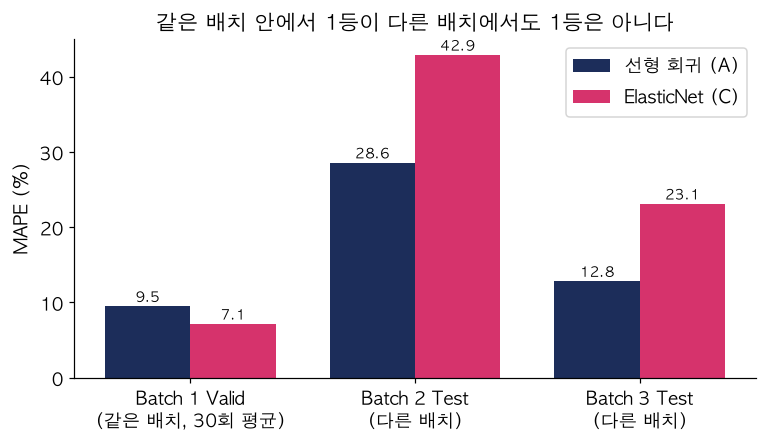

In [20]:
# 같은 배치 안 검증(Valid, seed 30번 평균) vs 다른 배치 테스트
fig, ax = plt.subplots(figsize=(8, 4))
pairs = [('선형 회귀', 'A'), ('ElasticNet', 'C')]
vals = {f'{m} ({f})': [stab.loc[(m, f), '평균'],
                        posthoc.query('모델 == @m and 피처세트 == @f').b2_MAPE.iloc[0],
                        posthoc.query('모델 == @m and 피처세트 == @f').b3_MAPE.iloc[0]] for m, f in pairs}
x = np.arange(3); w = .38
for i, (k, v) in enumerate(vals.items()):
    bars = ax.bar(x + (i - .5) * w, v, w, label=k, color=['#1C2D5A', '#d6336c'][i])
    ax.bar_label(bars, fmt='%.1f', fontsize=9)
ax.set_xticks(x, ['Batch 1 Valid\n(같은 배치, 30회 평균)', 'Batch 2 Test\n(다른 배치)', 'Batch 3 Test\n(다른 배치)'])
ax.set_ylabel('MAPE (%)'); ax.set_title('같은 배치 안에서 1등이 다른 배치에서도 1등은 아니다'); ax.legend()
viz.save(fig, 'm5_in_batch_vs_cross_batch')

**해석 (예상 H3·H4·H5 확인)**

- **H3 충전 정책 추가(B)**: Batch 3는 12.8 → 12.1%로 조금 좋아졌지만 Batch 2는 28.6 → 29.6%로 나빠졌다. 확실한 개선은 없다. 테스트 배치에서는 평균 C-rate가 사실상 상수라 더할 정보가 거의 없다.
- **ElasticNet(C) — 오늘 가장 큰 교훈**: Batch 1 안에서는 1등 후보였는데(§2-1), 다른 배치에서는 Batch 2 42.9%, Batch 3 23.1%로 **선형(A)보다 훨씬 나쁘다**. 배치마다 출발점이 다른 현장 피처(초기 용량·충전 시간)를 함께 배웠기 때문이다. DAY 1 4.5에서 "배치마다 부호가 바뀌는 피처는 위험"하다고 했던 것이 실제로 확인됐다. 같은 배치 안에서 검증만 하면 이런 위험을 잡을 수 없고, **'배치가 바뀌어도 방향이 같은가'라는 EDA 기준이 검증 점수보다 중요했다.** 선택 규칙 ③(CV–Valid 차이 3.5%p)이 seed 42에서는 이 위험을 걸러 냈지만, 운이 따른 면도 있다.
- **H4 현장 피처만(D)**: 테스트에서도 가장 나쁜 축이다. 배치마다 시작 용량이 달라(02 노트북) 원값 피처가 배치를 넘어가면 흔들린다.
- **H5 트리 모델**: '예측최대' 열을 보면 트리의 예측은 학습 최대 수명 근처에서 멈춘다. 그래서 Batch 3 최장수명 셀들을 크게 짧게 예측하고(최장 10셀 오차 중앙값), 최소 수명 위반도 많다. 선형은 학습 범위 밖도 예측해 이 문제가 덜하다.
- 평균 예측은 Batch 2 59%, Batch 3 24%로, 선형 모델이 오차를 절반 이하로 줄였다.
- Batch 2 기존 방식은 **모든 후보가 크게 틀린다**(31.9~84.8%). 모델이나 피처 선택의 문제가 아니라 데이터(배치) 자체의 차이라는 §5 결론을 뒷받침한다.

## 8. (참고) 예측 시점을 50사이클로 앞당기면

DAY 1 보고서 4.3에서 "50사이클은 빠르지만 덜 정확한 선택지로 나중에 확인"한다고 했다. 같은 선형 회귀(ΔQ 1개)로 ΔQ₅₀₋₁₀을 써 본다.

In [21]:
df50 = build_dataset(pred_cycle=50)
FEATURE_SETS['A50'] = ['dq50_logvar']
T.CANDIDATES['선형 회귀'] = (T.CANDIDATES['선형 회귀'][0], {}, ['A', 'A50'])
ok50 = df50[df50.status == 'OK']; b1_50 = ok50[ok50.batch == 'b1'].reset_index(drop=True)
tr50, va50 = T.split_batch1(b1_50)
rows = []
for f in ['A', 'A50']:
    gs, cv = T.tune('선형 회귀', f, tr50)
    v = T.mape(va50.cycle_life, gs.predict(va50[FEATURE_SETS[f]]))
    mdl, _ = T.final_fit('선형 회귀', f, b1_50)
    p = T.predict_table(mdl, f, df50); q = p[p.status == 'OK']
    rows.append({'예측 시점': '100사이클' if f == 'A' else '50사이클', 'Train CV': cv, 'Valid': v,
                 'Batch 2': T.mape(*q[q.batch == 'b2'][['cycle_life', 'pred']].values.T),
                 'Batch 3': T.mape(*q[q.batch == 'b3'][['cycle_life', 'pred']].values.T)})
pd.DataFrame(rows).round(2)

,예측 시점,Train CV,Valid,Batch 2,Batch 3
0,100사이클,9.03,9.29,28.56,12.81
1,50사이클,12.28,10.36,39.31,15.76


**해석**: 50사이클(하루 1회 기준 약 1.5개월 빨리)에 예측하면 Batch 2 28.6 → 39.3%, Batch 3 12.8 → 15.8%로 오차가 커진다. 운영사 입장에서는 '빨리 알기'와 '정확히 알기' 사이의 선택이다. 100사이클을 메인으로 두고, 50사이클은 *1차 경보*(위험 후보만 먼저 표시) 용도로 쓰는 2단계 운영을 생각할 수 있다.

## 9. (참고) 새 배치의 일부 셀로 기준을 보정하면

DAY 1 보고서 4.6·6장에서 "새 로트는 일부를 먼저 확인한 뒤 예측 기준을 보정"하자고 제안했다. 그게 실제로 효과가 있는지 실험한다.

- 방법: Batch 2에서 수명이 끝난 셀 k개를 무작위로 뽑아 '모델이 평균적으로 얼마나 길게 보는지'(log 오차 평균)를 구하고, 나머지 셀 예측에서 그만큼 빼 준다. 200번 반복.
- **공식 성능표와 분리**: 테스트 정답 일부를 쓰는 실험이므로 Test 성능으로 보고하지 않는다. 현장에서는 '새 로트 중 먼저 수명이 끝난 몇 개'에 해당한다.

In [22]:
rng = np.random.default_rng(0)
def recal(dd, k, n=200):
    out = []
    for _ in range(n):
        idx = rng.choice(len(dd), k, replace=False); rest = np.setdiff1d(np.arange(len(dd)), idx)
        shift = np.mean(np.log10(dd.pred.values[idx]) - np.log10(dd.cycle_life.values[idx]))
        p = 10 ** (np.log10(dd.pred.values[rest]) - shift)
        out.append((T.mape(dd.cycle_life.values[rest], p), T.over_ratio(dd.cycle_life.values[rest], p)))
    return np.mean(out, axis=0)
d2 = po[po.batch == 'b2'].reset_index(drop=True)
rows = [{'보정에 쓴 셀 수': 0, 'MAPE': T.mape(d2.cycle_life, d2.pred), '과대예측(%)': T.over_ratio(d2.cycle_life, d2.pred)}]
for k in [3, 5, 10]:
    m, o = recal(d2, k); rows.append({'보정에 쓴 셀 수': k, 'MAPE': m, '과대예측(%)': o})
recal_tbl = pd.DataFrame(rows); recal_tbl.round(1)

,보정에 쓴 셀 수,MAPE,과대예측(%)
0,0,28.6,97.4
1,3,12.3,51.2
2,5,11.4,53.8
3,10,10.9,54.5


**해석**: 셀 5개만 써도 Batch 2 MAPE가 28.6% → 약 11.4%로 줄고, 과대예측 비율도 97% → 54%로 균형이 맞는다. 새 배치에서 먼저 끝난 셀 몇 개만으로 '이 배치는 전체적으로 짧게 산다'는 치우침을 상당 부분 바로잡을 수 있다. 남는 오차는 배치 *안의* 차이(그룹 혼재, 평평한 관계) 때문이다. → 운영 제안: **새 로트 도입 시 소수 셀을 먼저 수명 끝까지 돌려(또는 가속 시험) 기준을 보정**하는 절차가 모델 자체를 바꾸는 것보다 효과가 크다.

## 10. 비용으로 환산 (DAY 1 보고서 6장 약속)

DAY 1에서 "실제 절감액은 DAY 2의 예측 오차를 이 비용에 대입해 계산"한다고 했다. 운영 가정을 단순하게 두고 계산한다.

- 하루 1회 충방전 → 1사이클 = 1일
- 셀 교체비 1MWh당 $30,000~$80,000 (과제 자료)
- **짧게 예측(과소)**: 아직 쓸 수 있는 배터리를 미리 교체 → 낭비 = 교체비 × (버린 수명 비율)
- **길게 예측(과대)**: 교체 계획이 늦어져 그 기간 동안 갑작스러운 정지 위험에 노출 → 늦어진 일수로 표시 (정지 손실 금액은 현장 데이터가 없어 계산하지 않음)
- 비교 대상: 모델 없이 '평균 수명'으로 일괄 계획한 경우

In [23]:
base, _ = T.final_fit('평균 예측', 'A', b1)
pb = T.predict_table(base, 'A', df)
def money(p, b):
    d = p[(p.status == 'OK') & (p.batch == b)]
    under = d[d.pred < d.cycle_life]; over = d[d.pred > d.cycle_life]
    waste = ((under.cycle_life - under.pred) / under.cycle_life)
    return {'MAPE': T.mape(d.cycle_life, d.pred),
            '과소예측 셀': len(under), '버린 수명 평균(%)': waste.mean() * 100 if len(under) else 0,
            '낭비 $/MWh (하한~상한)': f"{waste.sum() / len(d) * 30000:,.0f} ~ {waste.sum() / len(d) * 80000:,.0f}",
            '과대예측 셀': len(over), '교체 지연 중앙값(일)': (over.pred - over.cycle_life).median() if len(over) else 0}
cost = pd.DataFrame({(b, nm): money(p, b) for b in ['b2', 'b3'] for nm, p in [('평균 예측', pb), ('선형 회귀(ΔQ)', pred)]}).T
cost

MAPE 과소예측 셀 버린 수명 평균(%) 낭비 $/MWh (하한~상한) 과대예측 셀 교체 지연 중앙값(일)
b2 평균 예측      59.077806      9   15.813368    1,095 ~ 2,919     30   323.900879
   선형 회귀(ΔQ)  28.559472      1    8.093519         62 ~ 166     38   152.986424
b3 평균 예측       24.33397     40   25.122535   6,852 ~ 18,271      4    75.900879
   선형 회귀(ΔQ)  12.814065     19    13.00587    1,685 ~ 4,493     25      75.8945

**해석**

- '낭비 $/MWh'는 테스트 셀 전체를 평균했을 때 MWh당 조기 교체로 버리는 금액이다. Batch 3에서 모델을 쓰면 평균 예측 대비 낭비가 약 $6,900~18,300 → $1,700~4,500로 약 75% 줄어든다.
- Batch 2에서는 거의 모든 셀을 길게 예측해서 '낭비'는 작지만, 대신 **교체가 약 150일(5개월) 늦어지는 위험**이 남는다. 평균 예측(약 320일 지연)보다는 절반으로 줄었다. 금액만 보면 좋아 보이는데 실제로는 더 위험한 상태다 → 비용을 볼 때도 과소/과대를 나눠 봐야 한다.
- 정지 손실(위약금, 피크 대응 실패)은 현장 계약 조건이 있어야 계산할 수 있어 한계로 남긴다.

## 11. 그래서 운영에서는 어떻게 쓰나 — 보수적 교체 기준

수명을 **길게** 보면 교체가 늦어져 갑작스러운 정지가 생기고, **짧게** 보면 아직 쓸 수 있는 배터리를 버린다. 둘 중 앞쪽이 더 위험하다(정지·위약금). 그래서 예측 수명을 그대로 쓰지 말고 **조금 줄여서(여유를 두고)** 교체를 계획하는 게 맞다고 봤다.

- 얼마나 줄일지는 **Batch 1 안의 오차**로만 정한다 (테스트 배치로 정하면 다시 정답을 보는 셈).
- Batch 1 교차검증 예측(각 셀이 학습에 안 쓰였을 때의 예측)에서 '실제/예측' 비율을 구하고, 그 하위 10%·20% 값을 계수로 쓴다.
- 그 계수를 Batch 3·2에 적용해 과대예측과 비용이 어떻게 바뀌는지 본다.

In [24]:
from sklearn.model_selection import cross_val_predict, GroupKFold
oof = cross_val_predict(T.CANDIDATES['선형 회귀'][0], b1[FEATURE_SETS['A']], b1.cycle_life,
                        groups=b1.group, cv=GroupKFold(n_splits=5))
ratio = b1.cycle_life / oof
print(f'Batch 1 교차검증 MAPE {T.mape(b1.cycle_life.values, oof):.2f}%')
print('실제/예측 비율 하위 10% / 20% / 중앙값:', np.percentile(ratio, [10, 20, 50]).round(3))

def plan(d, k):
    p, y = d.pred.values * k, d.cycle_life.values
    under = p < y; waste = ((y - p) / y)[under]
    return {'과대예측(%)': np.mean(p > y) * 100,
            '교체 지연 중앙값(일)': np.median((p - y)[p > y]) if (p > y).any() else 0,
            '조기 교체로 버린 수명 평균(%)': waste.mean() * 100 if under.any() else 0,
            '낭비 $/MWh': f"{waste.sum() / len(y) * 30000:,.0f} ~ {waste.sum() / len(y) * 80000:,.0f}"}

rules = [('예측 그대로', 1.0), ('하위 20% 기준', np.percentile(ratio, 20)), ('하위 10% 기준', np.percentile(ratio, 10))]
cons = pd.DataFrame([{'배치': b, '교체 기준': nm, '계수': round(k, 3), **plan(po[po.batch == b], k)}
                     for b in ['b3', 'b2'] for nm, k in rules])
cons.round({'과대예측(%)': 1, '교체 지연 중앙값(일)': 0, '조기 교체로 버린 수명 평균(%)': 1})

Batch 1 교차검증 MAPE 8.54%
실제/예측 비율 하위 10% / 20% / 중앙값: [0.9   0.916 0.992]


,배치,교체 기준,계수,과대예측(%),교체 지연 중앙값(일),조기 교체로 버린 수명 평균(%),낭비 $/MWh
0,b3,예측 그대로,1.000,56.8,76.0,13.0,"1,685 ~ 4,493"
1,b3,하위 20% 기준,0.916,31.8,54.0,14.6,"2,995 ~ 7,988"
2,b3,하위 10% 기준,0.900,27.3,42.0,15.2,"3,318 ~ 8,849"
3,b2,예측 그대로,1.000,97.4,153.0,8.1,62 ~ 166
4,b2,하위 20% 기준,0.916,84.6,102.0,6.1,283 ~ 756
5,b2,하위 10% 기준,0.900,84.6,92.0,7.8,359 ~ 958


In [25]:
# Batch 2: 여유만 두는 것 vs 로트 보정(먼저 확인한 셀 5개) + 여유
rng = np.random.default_rng(0); k10 = np.percentile(ratio, 10); rows = []
d2 = po[po.batch == 'b2'].reset_index(drop=True)
for _ in range(200):
    idx = rng.choice(len(d2), 5, replace=False); rest = d2.drop(index=idx)
    shift = np.mean(np.log10(d2.pred[idx]) - np.log10(d2.cycle_life[idx]))
    p = 10 ** (np.log10(rest.pred) - shift) * k10
    rows.append((np.mean(p > rest.cycle_life) * 100, T.mape(rest.cycle_life, p)))
print(f'Batch 2, 여유 10%만: 과대예측 {plan(d2, k10)["과대예측(%)"]:.0f}%')
print(f'Batch 2, 로트 보정(5셀) + 여유 10%: 과대예측 {np.mean([r[0] for r in rows]):.0f}%, MAPE {np.mean([r[1] for r in rows]):.1f}%')

Batch 2, 여유 10%만: 과대예측 85%
Batch 2, 로트 보정(5셀) + 여유 10%: 과대예측 23%, MAPE 12.7%


**내 판단**

- **같은 로트(Batch 3처럼 학습과 관계가 같은 배치)**에서는 예측 수명의 약 90% 시점에 교체를 준비하면, 수명을 길게 본 셀이 절반 이상에서 4분의 1 정도로 줄어든다. 대신 조기 교체 낭비가 MWh당 약 $1,600~4,400 늘어난다(셀 하나당 버리는 수명이 평균 13% → 15%). 정지 한 번의 손실(피크 대응 실패, 위약금)이 이보다 크다면 여유를 두는 쪽이 맞다고 본다.
- **새 로트(Batch 2)**는 여유 10%로는 부족하다(과대예측 여전히 80%대). 배치 차이(약 −24%)가 여유보다 훨씬 크기 때문이다. 로트 보정(먼저 확인한 셀 5개)을 하고 여유를 더하면 과대예측이 85% → 약 23%로 줄고 MAPE는 약 12.7%다.
- 즉 운영 순서는 **① 새 로트는 먼저 보정 → ② 보정된 예측에 여유를 두고 교체 계획**이다. 모델 성능을 1~2%p 올리는 것보다 이 절차가 운영 위험을 더 많이 줄인다.